***
<span style="color:#008385">

**15-288: Machine Learning in a Nutshell**, *CMU-Qatar* Spring'26

**Gianni A. Di Caro**, www.giannidicaro.com

<u>Disclaimer:</u> This notebook was prepared for teaching purposes. It can include material from different web sources. I'll be happy to explicitly acknowledge a source if required. 
</span>
***

***
# <font color='red'>Installation: TensorFlow Keras + utilities, PyTorch

- For Keras, check the installation instructions in the Notebook 288-S25-23-NN-1.ipynb


- For PyTorch with CPU only:

  ```conda install pytorch torchvision torchaudio cpuonly -c pytorch```


- For PyTorch with GPU:

  ```conda install pytorch torchvision torchaudio pytorch-cuda -c pytorch -c nvidia```


Most of the code is with Keras. The final cells are with PyTorch.

***
# <font color='red'>Structure and Concepts behind the use of a CNN (for image classification)

<div>
<center>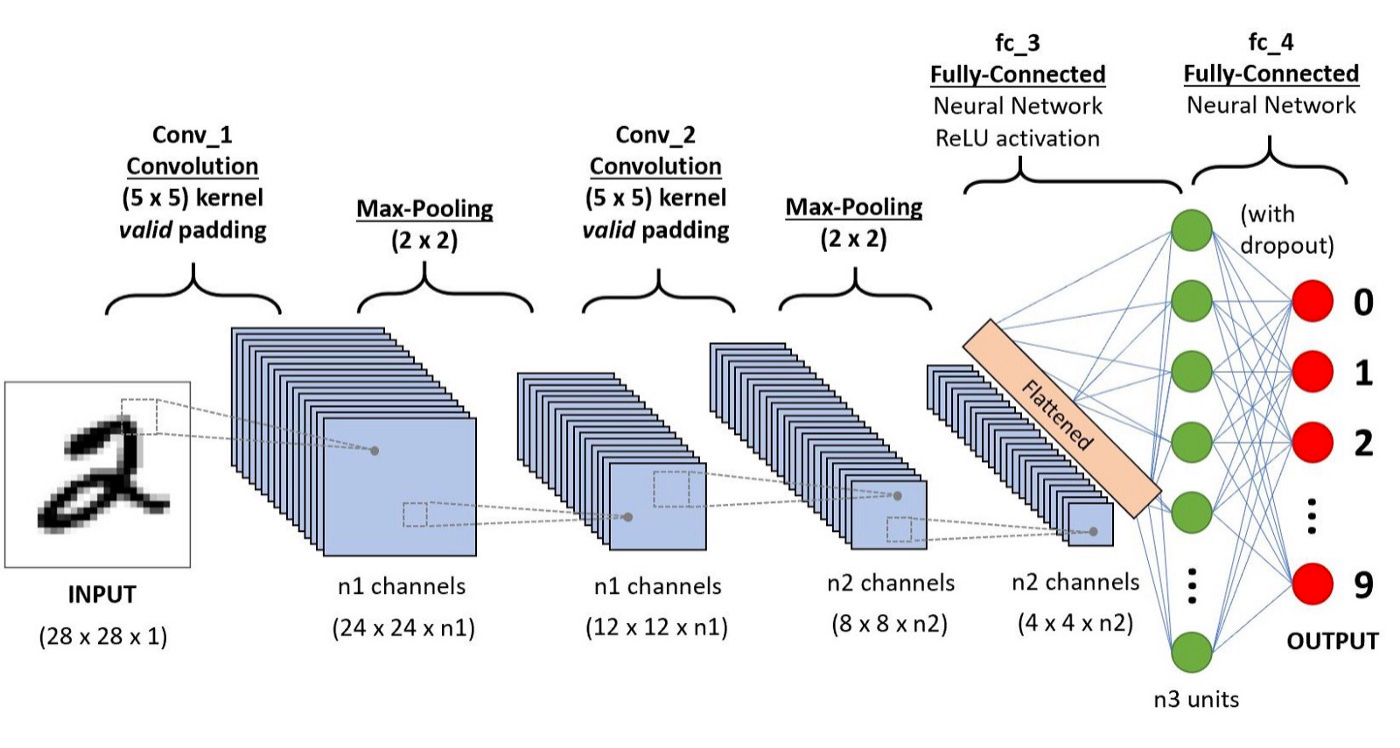</center>
</div>


The figure shows a general form of a CNN for image classification tasks. 

Note that, differently from the case of Fully-connected MLPs, the **input image is not flattened**. Instead it is passed as a regular image with a depth (corresponding to the number of image channels).

We will build a CNN with two consecutive convolutional layers, one max pooling layer, and two final fully connected layers.

In practice, when we will use the network, we will:
1. Get the **raw image as input** (not need to flatten it)

1. **Progressively extract high-level feature maps** through the two <font color='blue'>convolutional layers</font>

1. Extract more **high-level features** and **downsampling the features maps** with the <font color='blue'>max-pooling layer</font>

1. Use the  extracted feature maps as an **input for an MLP** (fully connected network) with <font color='blue'>one hidden layer</font> and a <font color='red'>soft-max activation for the output</font>

1. The input for the MLP part of the network **needs to be flattened**, as usual

1. The whole process can be seen as:
   1. <font color='blue'>using a CNN for extracting features from the raw image input,</font>
   
   1. and <font color='red'>using the extracted features as the input for a regular MLP that performs a probabilistic classification</font><br>

1. The *nice* part of the story is that <font color='green'>the feature extractor and the probabilistic classifier are **jointly trained**</font> (via backpropagation)

***
# <font color='red'>General imports

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi']= 180
import pandas as pd

import time
from time import process_time 

In [2]:
import keras
from keras.models import Sequential

In [3]:
from keras.layers import Input, Dense, Dropout, Activation, Flatten

More imports specific for CNNs will be done below

In [4]:
from keras.utils import to_categorical

***
# <font color='red'>Classification of MNIST image data with CNN

We'll follow steps similar to what we've done for MLPs. Refer to that notebook for some basic notions. Note that several utility functions will be identical between the two notebooks.

In [5]:
num_classes = 10 # classification of the digits from 0 to 9

In [6]:
from keras.datasets import mnist
 
# Load pre-shuffled MNIST data into train and test sets
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [7]:
print(X_train.shape)
# (60000, 28, 28)

(60000, 28, 28)


In [8]:
nrows = X_train.shape[1]
ncols = X_train.shape[2]

class_names = [str(d) for d in range(10) ]

print('The dataset consists of {} images {}x{}'.format(X_train.shape[0], 
                                                       nrows, ncols))
class_names

The dataset consists of 60000 images 28x28


['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [9]:
def visualize_images(features_img, labels_img, img_size=(28, 28), 
                     img_titles='Digit', class_names = [],
                     n=15, selection='deterministic',
                     cmap='gray'):

    if n < 6:
        print('ERROR: Number of images to visualize must be greater than 5!\n')
        return
    
    # transform the flat arrays into 2D images
    features_img_viz = features_img.reshape(features_img.shape[0], 
                                            img_size[0], img_size[1])
    features_img_viz = features_img_viz.astype(np.uint8)

    ncols = 5
    nrows = int(np.ceil(n / ncols))
    
    width = 14
    height = 2 * nrows
    fig, subplots = plt.subplots(nrows, ncols, figsize=(width, height))
    fig.subplots_adjust(top=0.85, hspace=0.5)
    
    if selection == 'deterministic':
        selection = np.arange(0, nrows * ncols, 1)
        selection = selection.reshape(nrows, ncols)
        print(selection)
    else:
        selection = np.random.choice(list(range(features_img_viz.shape[0])), 
                                     size = nrows * ncols, replace=False)
        selection = selection.reshape(nrows, ncols)

    p = 0
    for r in range(nrows):
        for c in range(ncols): 
            if p >= n:
                subplots[r,c].axis('off')
            else:
                subplots[r,c].axis('off')
                title = '{} {}'.format(img_titles, 
                                        class_names[labels_img[selection[r,c]]])
                
                subplots[r,c].set_title('{} [{}]'.format(title, 
                                                       labels_img[selection[r,c]]), 
                                                       fontsize=8)
                subplots[r,c].imshow(features_img_viz[selection[r,c]], 
                                     cmap=cmap)
            p += 1
    plt.show()

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]


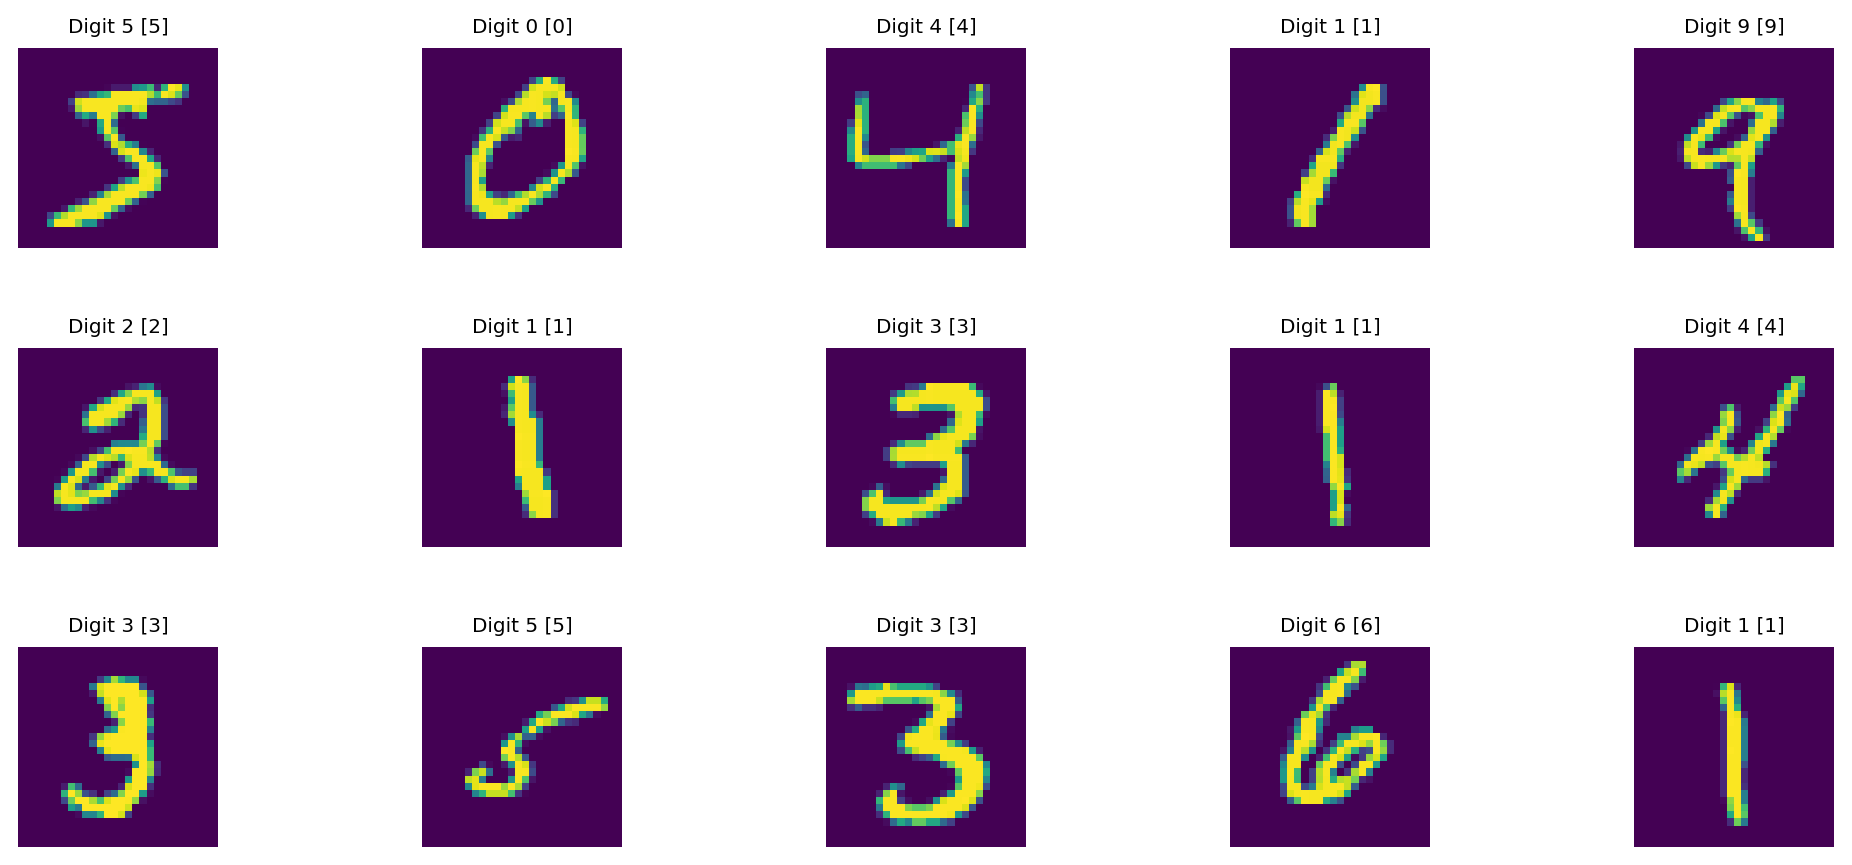

In [10]:
visualize_images(X_train, y_train, img_size=(nrows, ncols), 
                 img_titles='Digit',
                 class_names = class_names,
                 n=15, selection='deterministic',
                 cmap='viridis')


***
# <font color='red'>Preprocessing: change dimensions and ranges of features

When using the Theano backend, it is necessary to **explicitly declare a dimension for the depth of the input image.** For example, a full-color image with all 3 RGB channels will have a depth of 3.

MNIST images only have a depth of 1, but we must explicitly declare that.

In other words, we need to transform our dataset from having shape `(n, width, height)` to `(n, width, height, depth)`.

In [11]:
#Reshape input data to have 3D images
depth = 1
img_shape = (nrows, ncols, depth)

X_train = X_train.reshape(X_train.shape[0], *img_shape)
X_test = X_test.reshape(X_test.shape[0], *img_shape)

In [12]:
X_train.shape

(60000, 28, 28, 1)

A second preprocessing step for the input data is to convert the image pixel intensities to the range $[0, 1]$. At this aim, we have to divide the values by 255. However, to get the fractional division correct and have the data of the correct type, we need first to change to data type `float32` since it is originally `uint8`.

In [13]:
X_train.dtype

dtype('uint8')

In [14]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

***
# <font color='red'>Preprocessing: change the dimension of the label array

In [15]:
y_train.shape

(60000,)

In [16]:
y_train[0:15]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1], dtype=uint8)

Labels are integer values between 0 and 9 (the digit). However, the output of our NN will be an array of 10 elements, each assigning a probability for the output being one of the digits. 

Therefore, it is necessary to modify the labels into a **one-hot array of 10 distinct class labels.**

In [17]:
# Convert 1-dimensional class arrays to 10-dimensional class matrices
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

In [18]:
Y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

***
# <font color='red'>CNN model architecture

In [19]:
from keras.models import Sequential
from keras.layers import Input, Dense, Conv2D, Dropout, Flatten, MaxPooling2D

Let's start by defining a sequential model that takes in input an image.

The first hidden layer is a **convolutional layer** of <u>32 feature maps</u> each 
obtained by applying a convolutional kernel (3,3) with unit stride and a bias,
that results in 32 feature maps of size 26x26 (28-3+1, by sliding the kernel).

The `ReLU` activation function is used to transform the pre-activations. 

In [20]:
CNN_model = Sequential()

CNN_model.add(Input(shape=img_shape))
CNN_model.add(Conv2D(32, kernel_size=(3, 3)))
CNN_model.add(Activation('relu'))

***
The second hidden layer is also a **convolutional layer** equivalent to the first one.

In [21]:
CNN_model.add(Conv2D(32, kernel_size=(3, 3)))
CNN_model.add(Activation('relu'))

***
The third hidden layer is a **max-pooling** layer, aimed to reduce the dimensionality.

To favor generalization, during training, a **dropout** factor of 0.25 is applied to remove units during a weight optimization pass.

The output of the layer is **flattened,** to be used as input of a dense layer.

In [22]:
CNN_model.add(MaxPooling2D(pool_size=(2, 2)))
CNN_model.add(Dropout(0.25))
CNN_model.add(Flatten())

***
The fourth hidden layer is a dense (fully connected) layer. The activation function is a **ReLU**, and a quite strong drastic dropout is applied during training.

In [23]:
CNN_model.add(Dense(128))
CNN_model.add(Activation('relu'))
CNN_model.add(Dropout(0.5))

***
The last, output / visible layer is a dense (fully connected) layer with a **softmax** activation function, that outputs a probability for each one of the 10 classes / digits.

In [24]:
CNN_model.add(Dense(num_classes))
CNN_model.add(Activation('softmax'))

***
# <font color='red'>Summary and Visualization of the model

In [25]:
CNN_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 600,810 (2.29 MB)

 Trainable params: 600,810 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

***
**How to compute the number of parameters:**

- E.g., the first hidden layer is a convolutional layer of 32 feature maps, each 
obtained by applying a convolutional kernel (3,3) with unit stride and a bias,
that results in 32 feature maps of size 26x26 (28-3+1).

- This means that each feature map is defined by the weights (to be learned) of its (3,3) kernel, which is defined by 3x3=9 parameters. In addition, each map has a bias weights, that makes a total of (9+1) x 32 = 320 parameters.

- In the case of the second convolutional layer, since the first convolutional layer has learned 32 feature maps, the number of parameters (to learn) becomes (3 x 3 x 32) + (1x32)= 9248, where the second term is the bias term of each feature map.

- For max pooling there are no parameters to learn. 

- The fully connected layer between the 4608 units in the previous (flatten) layer and its 128 units requires 4608x128 + 128 (bias) = 589952 parameters.
***

***
# <font color='red'>Visualize the NN model

In [26]:
# need to install pydot and pydotplus with conda
#
import pydot
import pydotplus
keras.utils.pydot = pydot
from keras.utils import plot_model


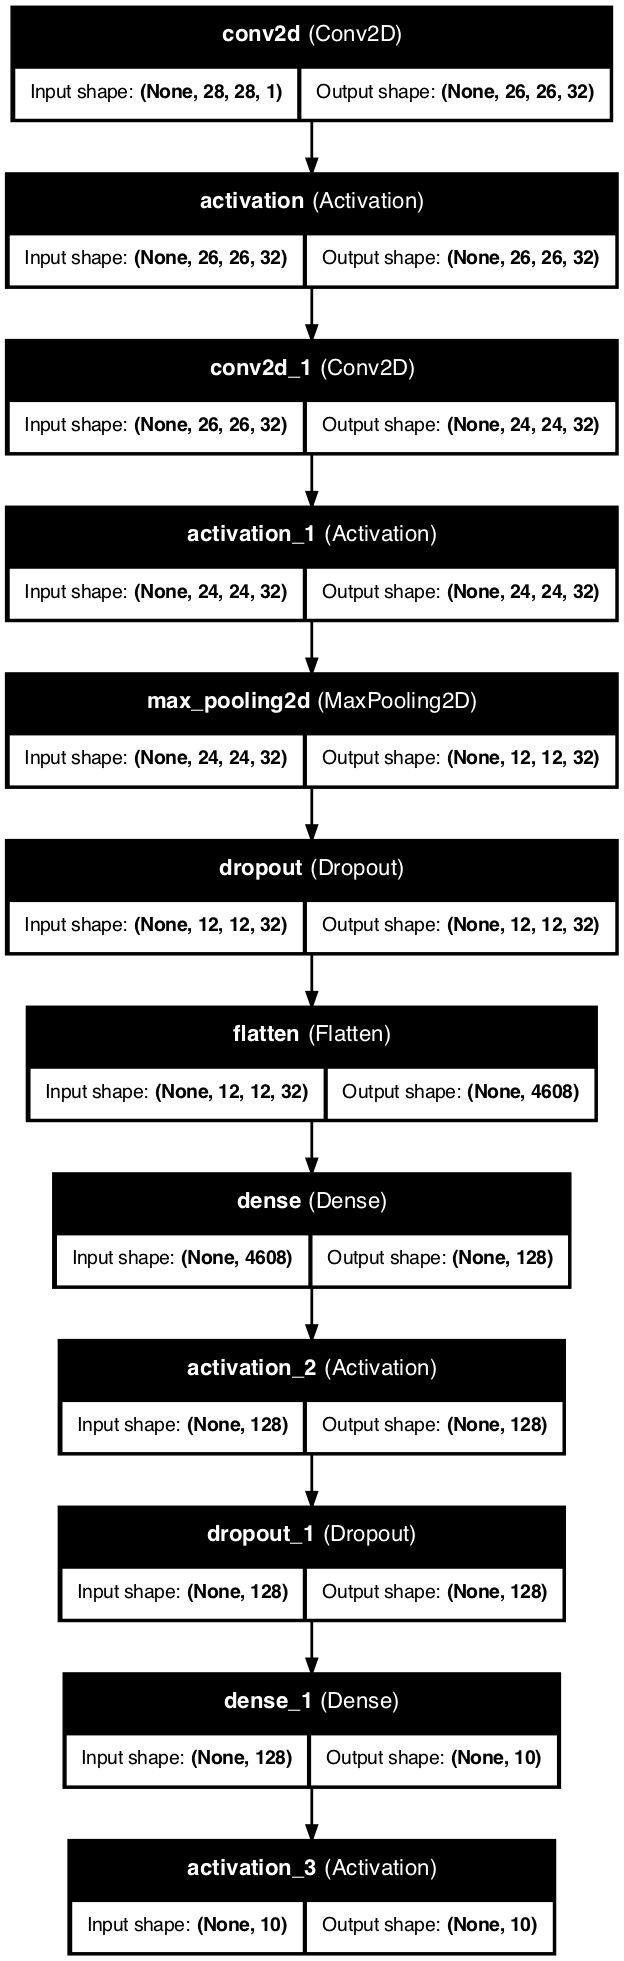

In [27]:
plot_model(CNN_model, show_shapes=True, show_layer_names=True,
           dpi=100) #to_file='model_plot.png', 

***
# <font color='red'>Rebuild the model using the functional API

For *some* reasons, when the model is built in the regula way, there's an error when we try to extract and visualize the layers.

The error magically disappears when the model is built using the functional API (!)

Therefore below, for the sake of showing the layers later, the model is rebuilt usin the function API

In [28]:
from keras.models import Model

inputs = Input(shape=img_shape)

x = Conv2D(32, kernel_size=(3, 3))(inputs)
x = Activation('relu')(x)
x = Conv2D(32, kernel_size=(3, 3))(x)
x = Activation('relu')(x)

x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)
x = Flatten()(x)

x = Dense(128)(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(num_classes)(x)
outputs = Activation('softmax')(x)

CNN_model = Model(inputs=inputs, outputs=outputs)

# Call the model once to make sure it's built
_ = CNN_model.predict(X_train[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


***
# <font color='red'>Compile the CNN model

In [29]:
CNN_model.compile(loss='categorical_crossentropy', 
                  optimizer='adam', metrics=['accuracy'])

***
# <font color='red'>Train the CNN model

In [30]:
n_data_train = int(0.3 * X_train.shape[0])
n_data_test = int(0.3 * X_test.shape[0])

$\to$ Running this will take some time! (about 15 minutes!), we might want to reduce the epochs!

In [31]:
# Train
batch_size = 128
epochs = 40

start_time = time.process_time()
        
training = CNN_model.fit(X_train[0:n_data_train], Y_train[0:n_data_train], 
                         batch_size=batch_size, 
                         epochs=epochs, 
                         validation_data=(X_test[0:n_data_test], 
                                          Y_test[0:n_data_test]),
                         verbose=2)
                         #callbacks=[checkpointer, early_stopping], 
    
print('\n\nTraining time: {:.3f} sec\n'.format(time.process_time() - start_time))

score = CNN_model.evaluate(X_test, Y_test, verbose=0)

print('Test score:', score[0])
print('Test accuracy:', score[1])

Epoch 1/40
141/141 - 4s - 30ms/step - accuracy: 0.8315 - loss: 0.5415 - val_accuracy: 0.9447 - val_loss: 0.1781
Epoch 2/40
141/141 - 4s - 26ms/step - accuracy: 0.9448 - loss: 0.1848 - val_accuracy: 0.9663 - val_loss: 0.1181
Epoch 3/40
141/141 - 3s - 25ms/step - accuracy: 0.9620 - loss: 0.1304 - val_accuracy: 0.9713 - val_loss: 0.0866
Epoch 4/40
141/141 - 4s - 25ms/step - accuracy: 0.9707 - loss: 0.0976 - val_accuracy: 0.9747 - val_loss: 0.0790
Epoch 5/40
141/141 - 4s - 25ms/step - accuracy: 0.9739 - loss: 0.0842 - val_accuracy: 0.9717 - val_loss: 0.0793
Epoch 6/40
141/141 - 4s - 26ms/step - accuracy: 0.9773 - loss: 0.0686 - val_accuracy: 0.9717 - val_loss: 0.0816
Epoch 7/40
141/141 - 3s - 24ms/step - accuracy: 0.9812 - loss: 0.0619 - val_accuracy: 0.9753 - val_loss: 0.0722
Epoch 8/40
141/141 - 3s - 25ms/step - accuracy: 0.9819 - loss: 0.0578 - val_accuracy: 0.9770 - val_loss: 0.0697
Epoch 9/40
141/141 - 4s - 25ms/step - accuracy: 0.9858 - loss: 0.0449 - val_accuracy: 0.9800 - val_loss:

***
# <font color='red'>Show learning curves

In [32]:
def show_learning_curves(learning_evolution, title=''):

    # list all data stored in the learning_evolution object
    print('Stored information:', [h for h in learning_evolution.history.keys()])

    # show evolution of accuracy
    plt.plot(learning_evolution.history['accuracy'])

    # show evolution of cross-validated accuracy
    if 'val_accuracy' in learning_evolution.history:
        plt.plot(learning_evolution.history['val_accuracy'])

    plt.title(title + 'Model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')

    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

    # show evolution of loss
    plt.plot(learning_evolution.history['loss'])
    
     # show evolution of cross-validated loss
    if 'val_accuracy' in learning_evolution.history:
        plt.plot(learning_evolution.history['val_loss'])

    plt.title(title + 'Model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

Stored information: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


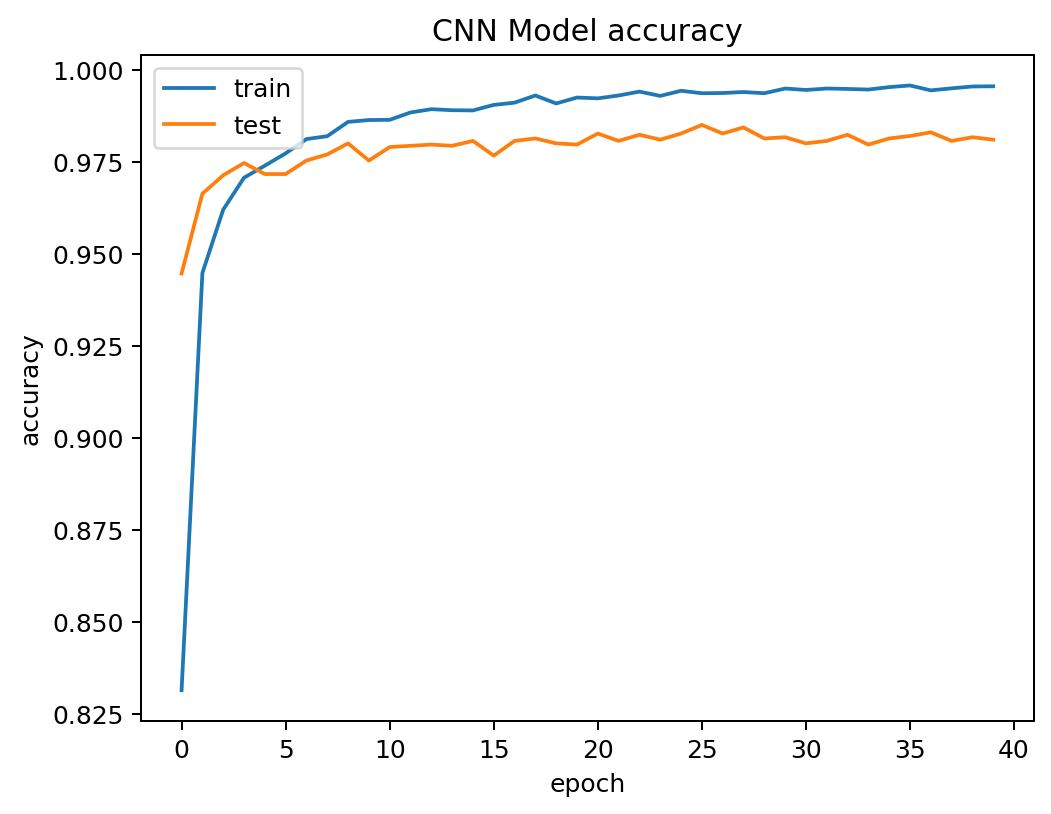

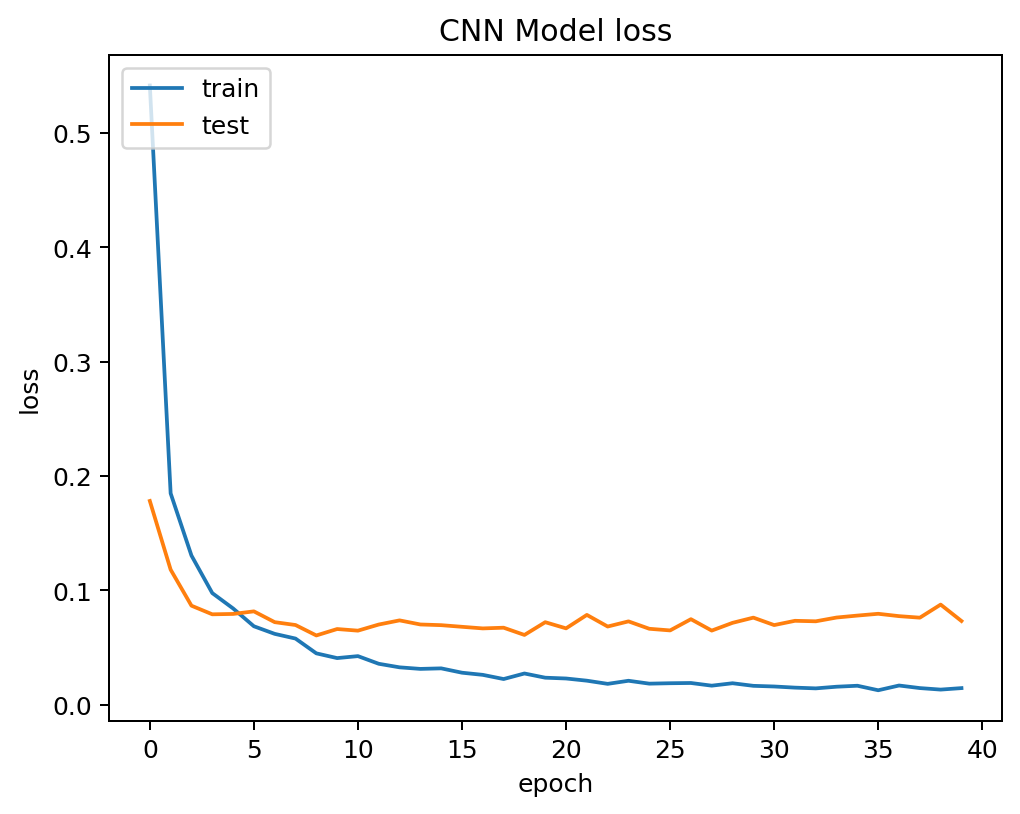

In [33]:
show_learning_curves(training, 'CNN ')

***
# <font color='red'>Visualize CNN layers

Each layer acts as a feature extractor, it learns a **feature map,** with the feature maps being more and more abstract and global(aggregate) with the depth of the layers in the network.

In [34]:
from keras.models import Model

def display_activation(activations, activation_index, 
                       ncols = 5, 
                       size=(12, 12), reshape=None): 
    
    activation = activations[activation_index]

    print('Shape of layer: ', activation.shape)
    
    if len(activation.shape) > 2:
        total_fmaps = activation.shape[-1] # the last axis of the array
        nrows = int(np.ceil(total_fmaps / ncols))
    else:
        total_fmaps = 1
        nrows,ncols = (1,1)

    feature_map=0
    
    if (ncols, nrows) == (1,1):
        plt.yticks([], [])
        plt.xticks(fontsize=6)
        if reshape == None:
            plt.imshow(activation[0].reshape(-1,1).T) #cmap='gray')
        else:
            plt.imshow(activation[0].reshape(reshape).T)
        return
        
    #fig, subplot = plt.subplots(nrows, ncols, figsize=size)
    fig = plt.figure(figsize=size)
    fig.subplots_adjust(hspace=0.23, wspace=0.22)
    
    for row in range(nrows):
        for col in range(ncols):
            subplot = fig.add_subplot(nrows, ncols, feature_map+1) 
            #subplot[row][col].imshow(activation[0, :, :, feature_map], 
            #                         cmap='gray')
            #subplot[row][col].tick_params(labelsize = 3)
            subplot.imshow(activation[0, :, :, feature_map])# cmap='gray')
            subplot.tick_params(labelsize = 3)    
            
            feature_map += 1
            if feature_map == total_fmaps:
                return


Get the information from the trained layers, including name and weights.

A sample image from the dataset is then passed to the network to classify. The activations (feature maps) from each functional layer are shown. 

In [35]:
layer_outputs = [layer.output for layer in CNN_model.layers]

layer_names = [layer.name.split('_')[0] for layer in CNN_model.layers]

#print(layer_outputs)

activation_model = Model(inputs=CNN_model.input, outputs=layer_outputs)

img_idx = 7
img_sample = X_train[img_idx].reshape(1, *img_shape)

activations = activation_model.predict(img_sample)

for a,_ in enumerate(activations):
    print('Activation Layer [{}]: {} {}'.format(a, layer_names[a],
                                                activations[a].shape))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Activation Layer [0]: input (1, 28, 28, 1)
Activation Layer [1]: conv2d (1, 26, 26, 32)
Activation Layer [2]: activation (1, 26, 26, 32)
Activation Layer [3]: conv2d (1, 24, 24, 32)
Activation Layer [4]: activation (1, 24, 24, 32)
Activation Layer [5]: max (1, 12, 12, 32)
Activation Layer [6]: dropout (1, 12, 12, 32)
Activation Layer [7]: flatten (1, 4608)
Activation Layer [8]: dense (1, 128)
Activation Layer [9]: activation (1, 128)
Activation Layer [10]: dropout (1, 128)
Activation Layer [11]: dense (1, 10)
Activation Layer [12]: activation (1, 10)


## <font color='red'>Input image / layer

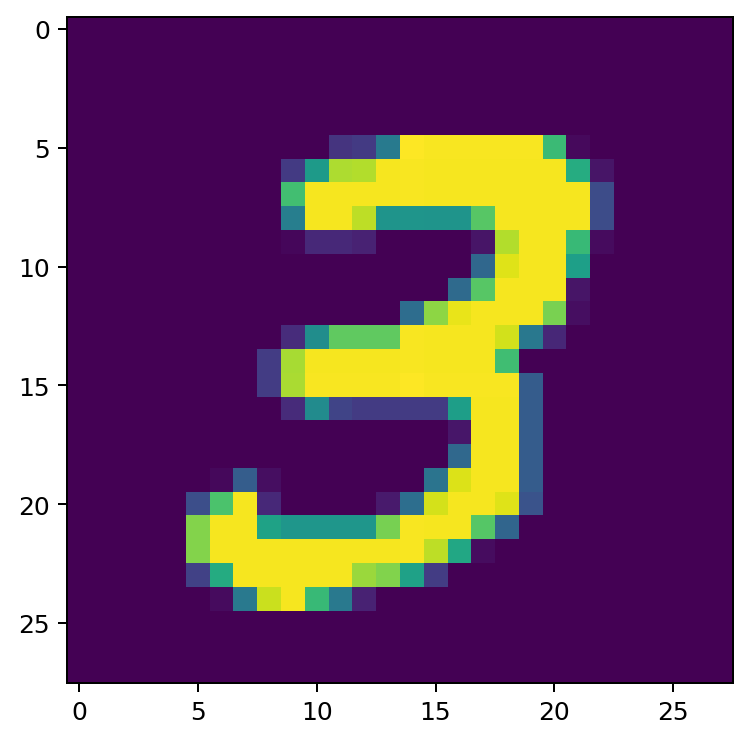

In [36]:
# original image
plt.imshow(X_train[img_idx][:,:,0]);

## <font color='red'>Feature maps at all layers

Type of layer:  input
Shape of layer:  (1, 28, 28, 1)


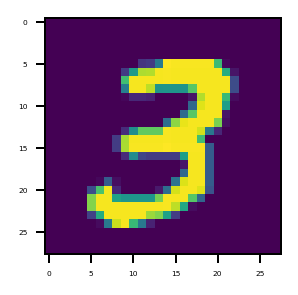

In [37]:
print('Type of layer: ', layer_names[0])
display_activation(activations, 0, 6, (12,12))

Type of layer:  conv2d
Shape of layer:  (1, 26, 26, 32)


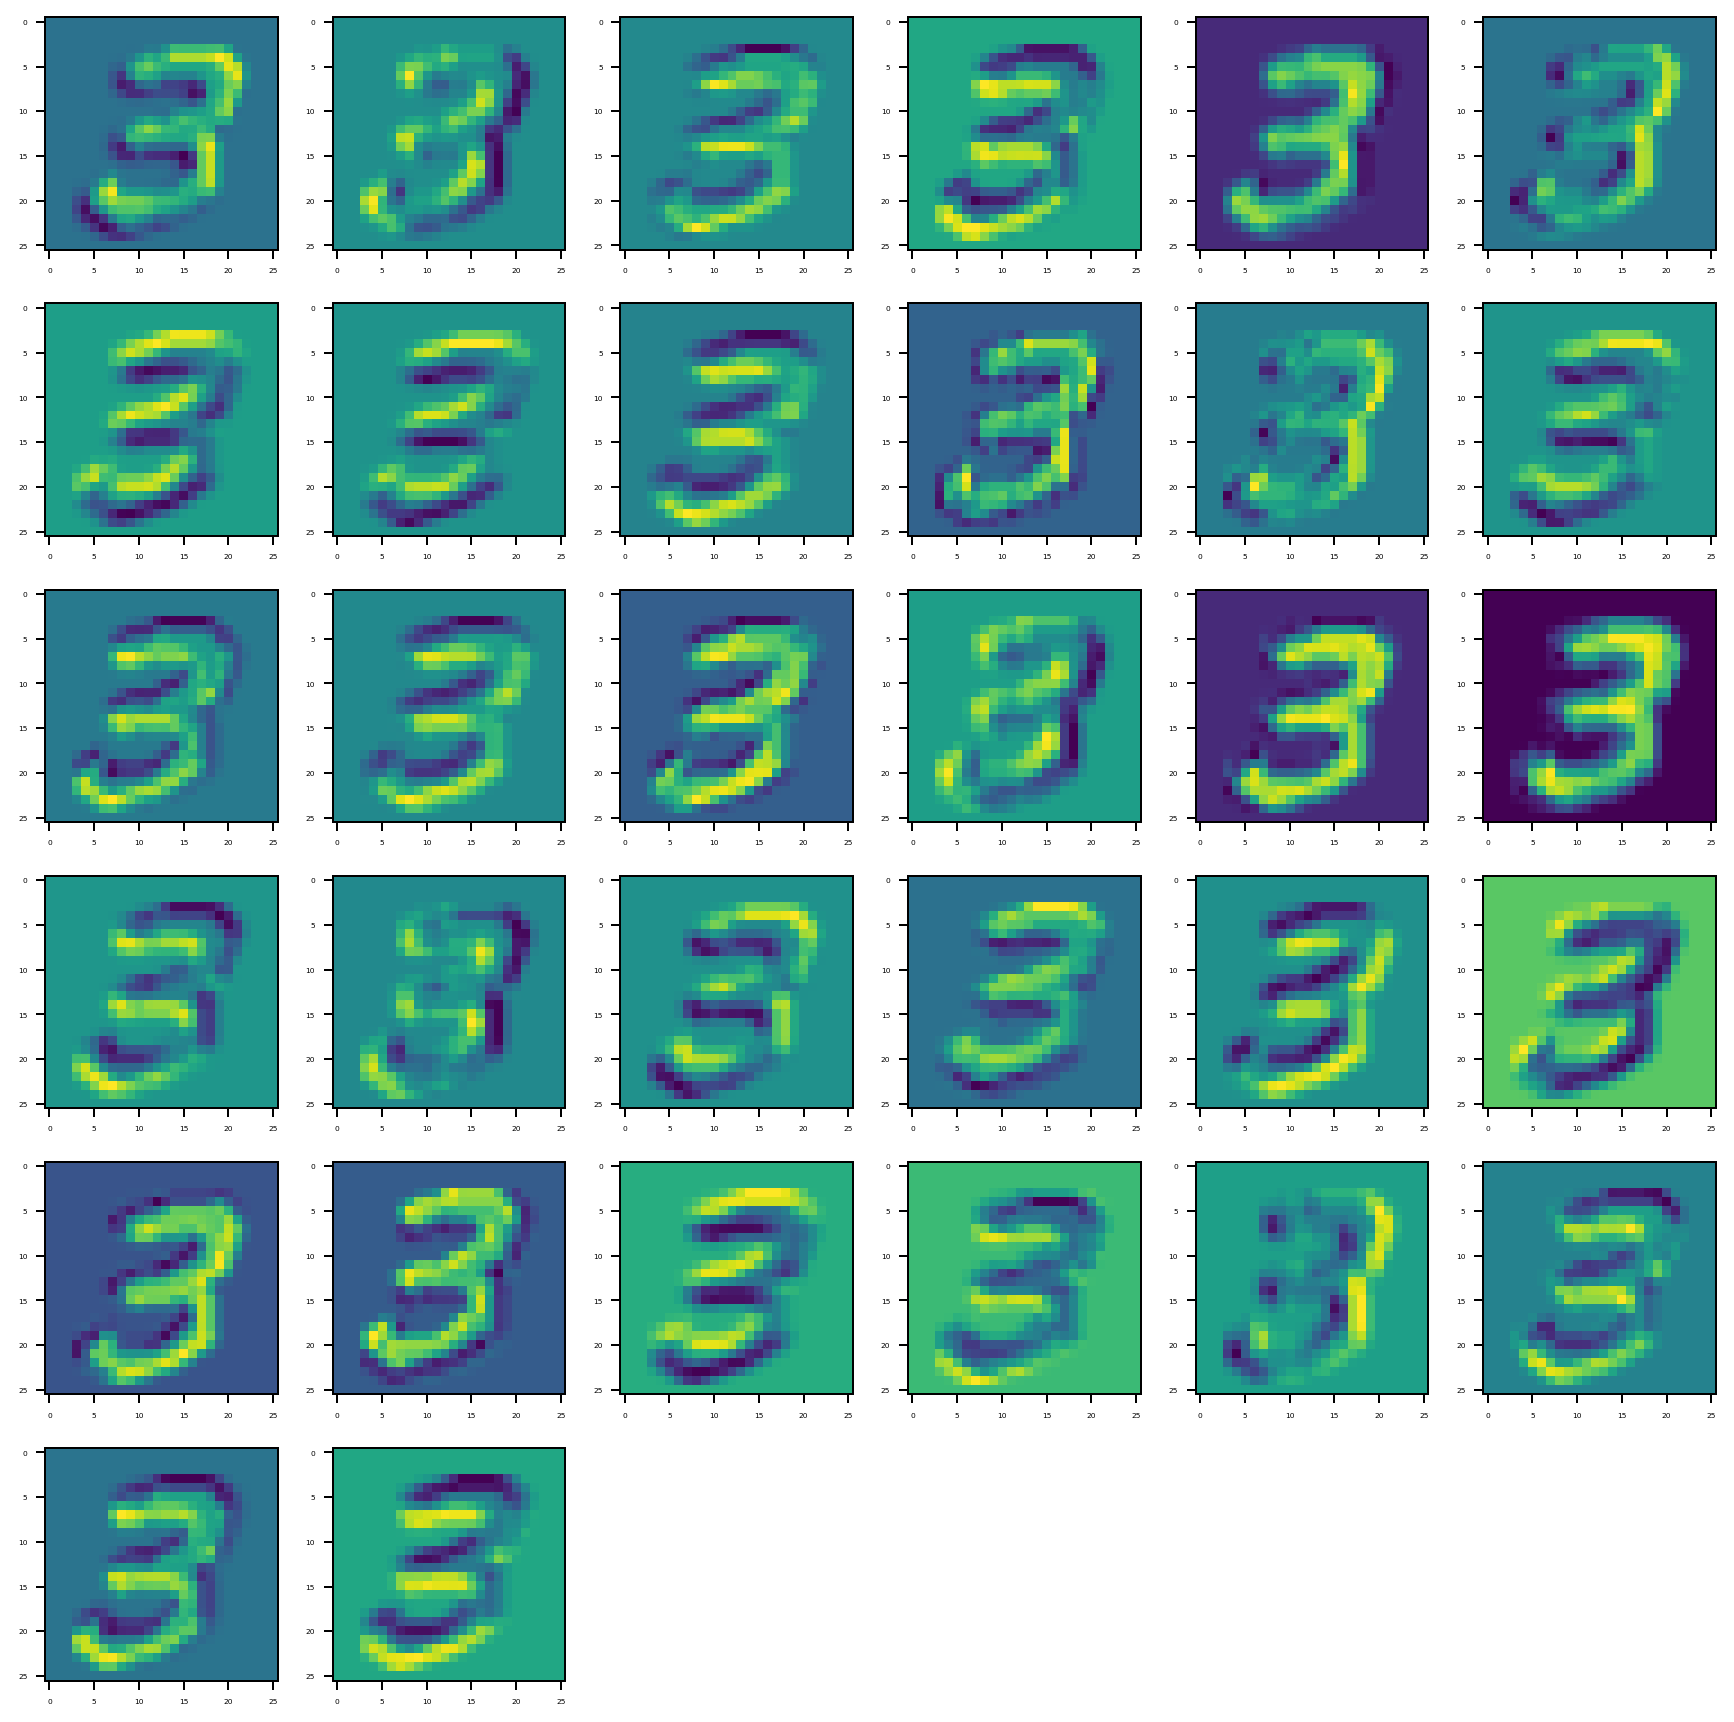

In [38]:
print('Type of layer: ', layer_names[1])
display_activation(activations, 1, 6, (12,12))

Type of layer:  activation
Shape of layer:  (1, 26, 26, 32)


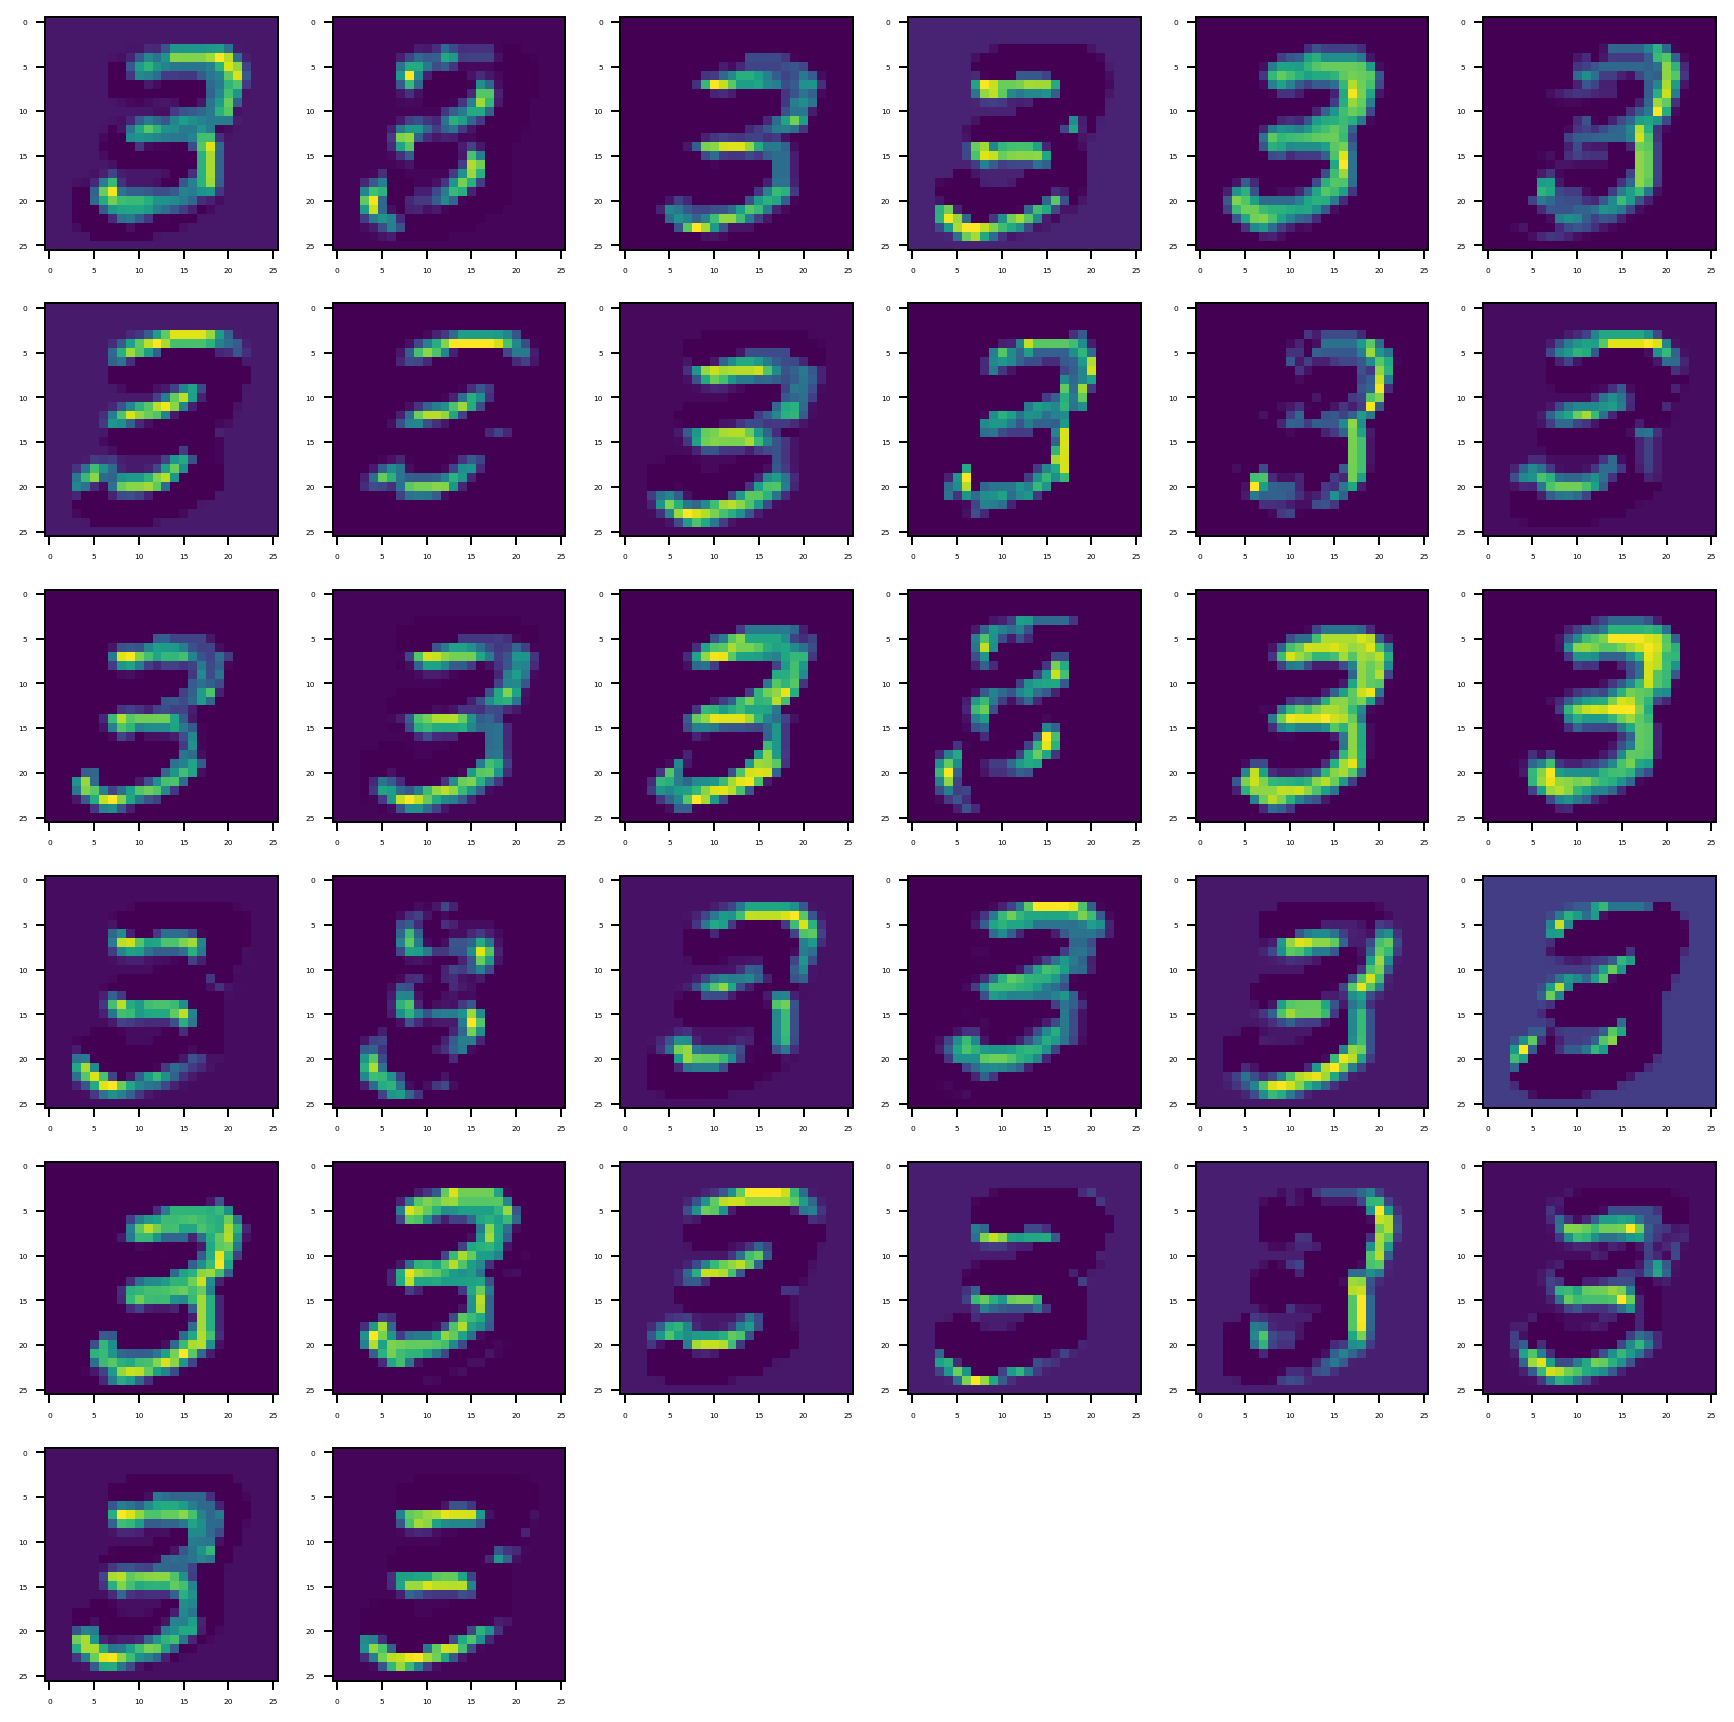

In [39]:
print('Type of layer: ', layer_names[2])
display_activation(activations, 2, 6, (12,12))

Type of layer:  conv2d
Shape of layer:  (1, 24, 24, 32)


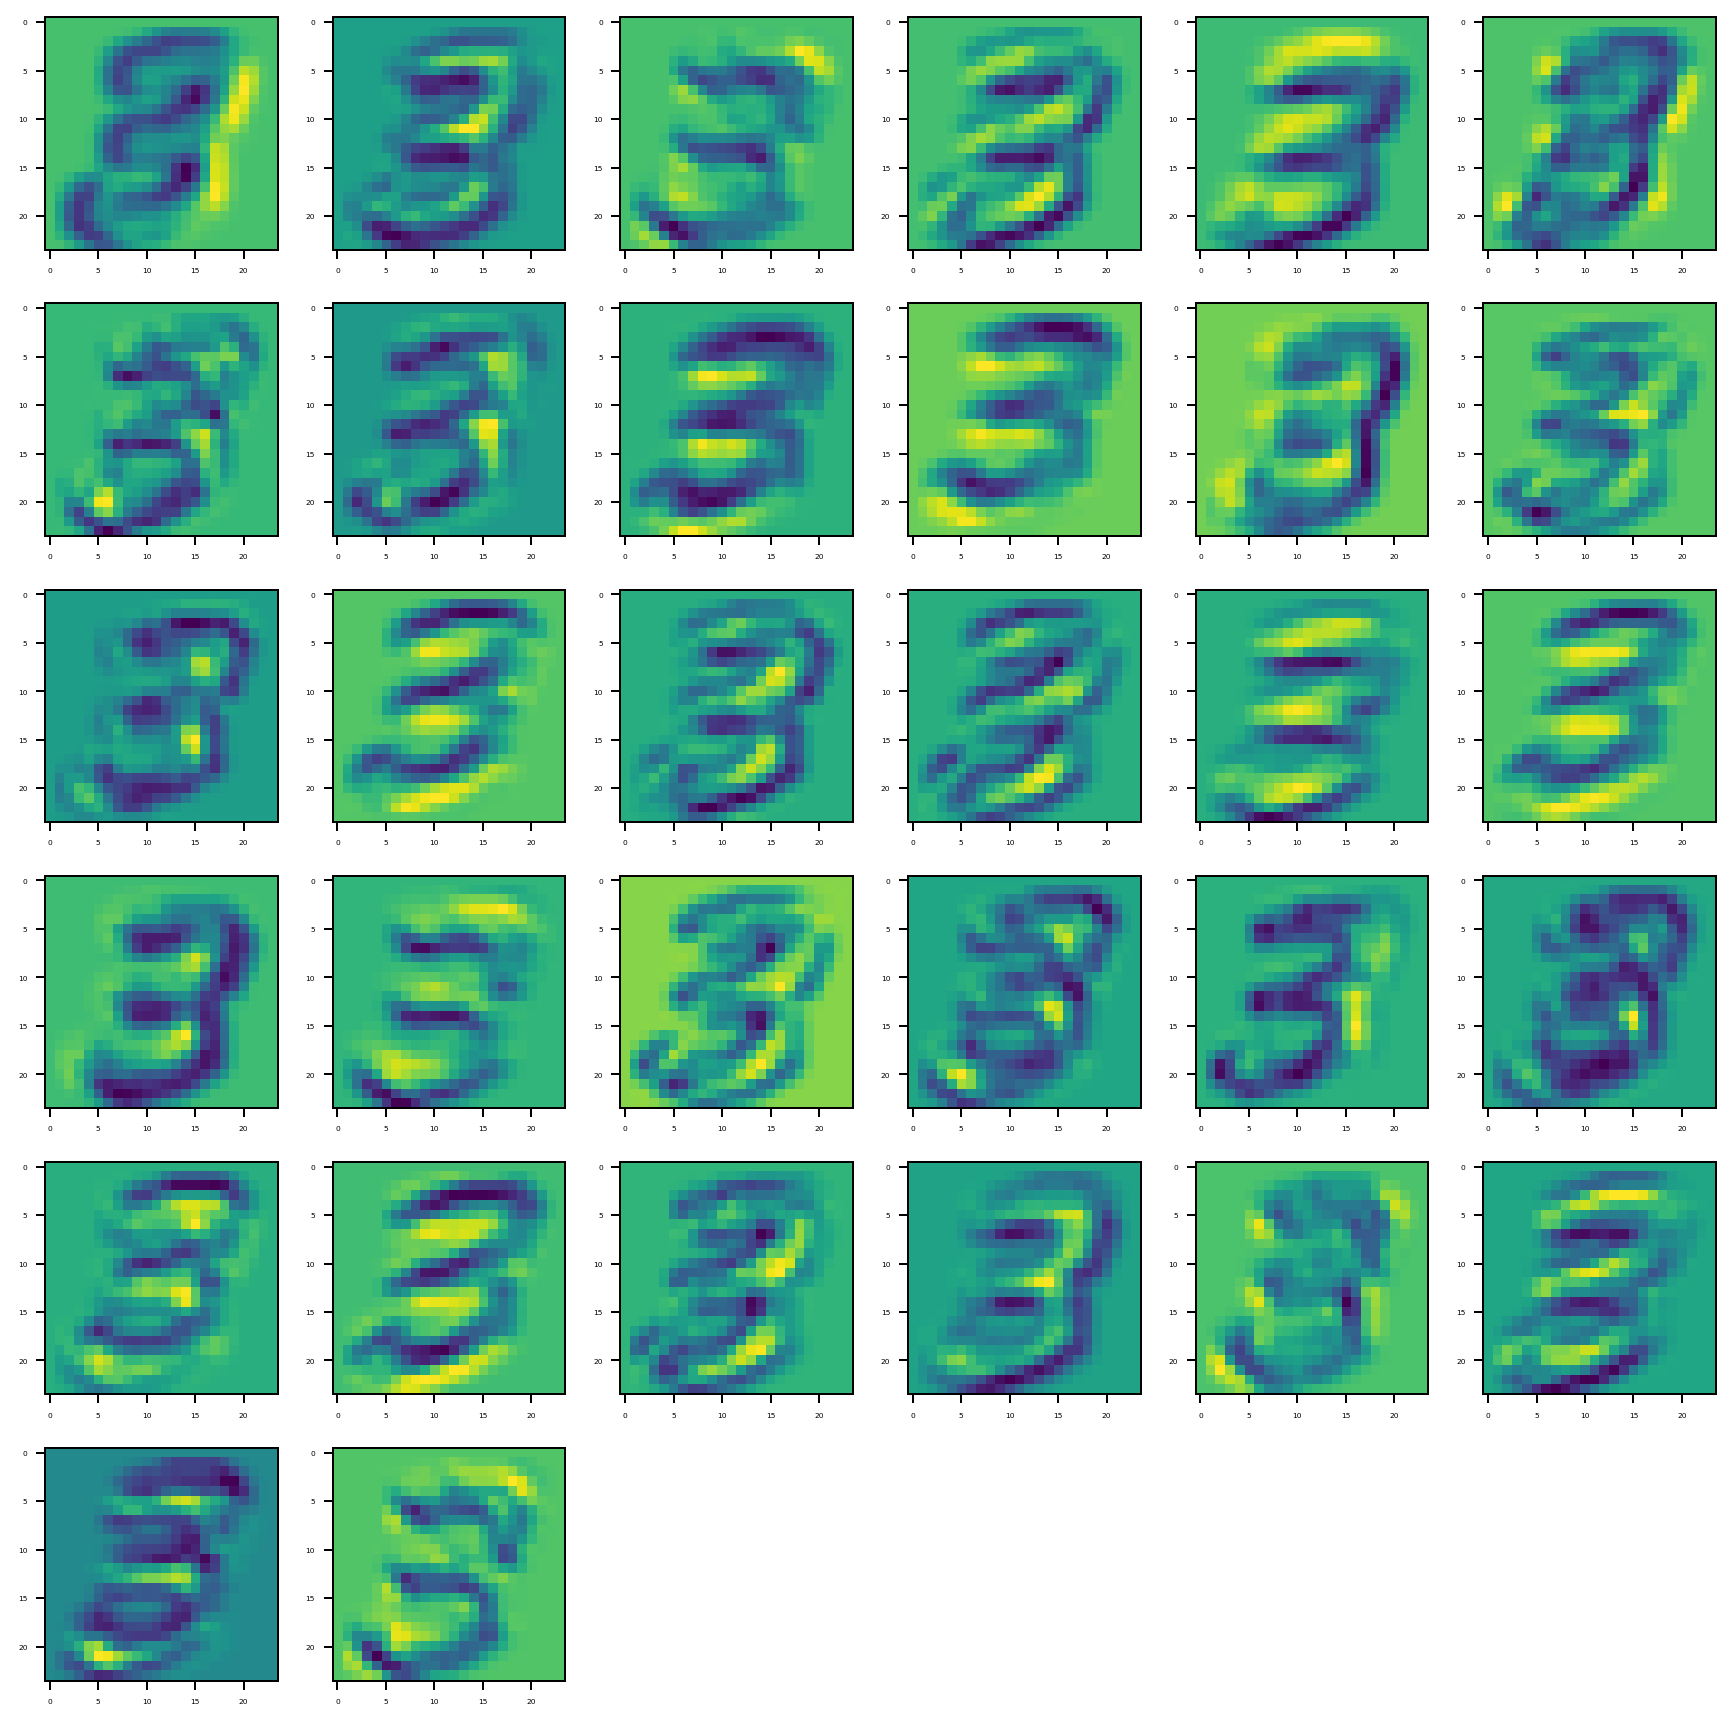

In [40]:
print('Type of layer: ', layer_names[3])
display_activation(activations, 3, 6)

Type of layer:  activation
Shape of layer:  (1, 24, 24, 32)


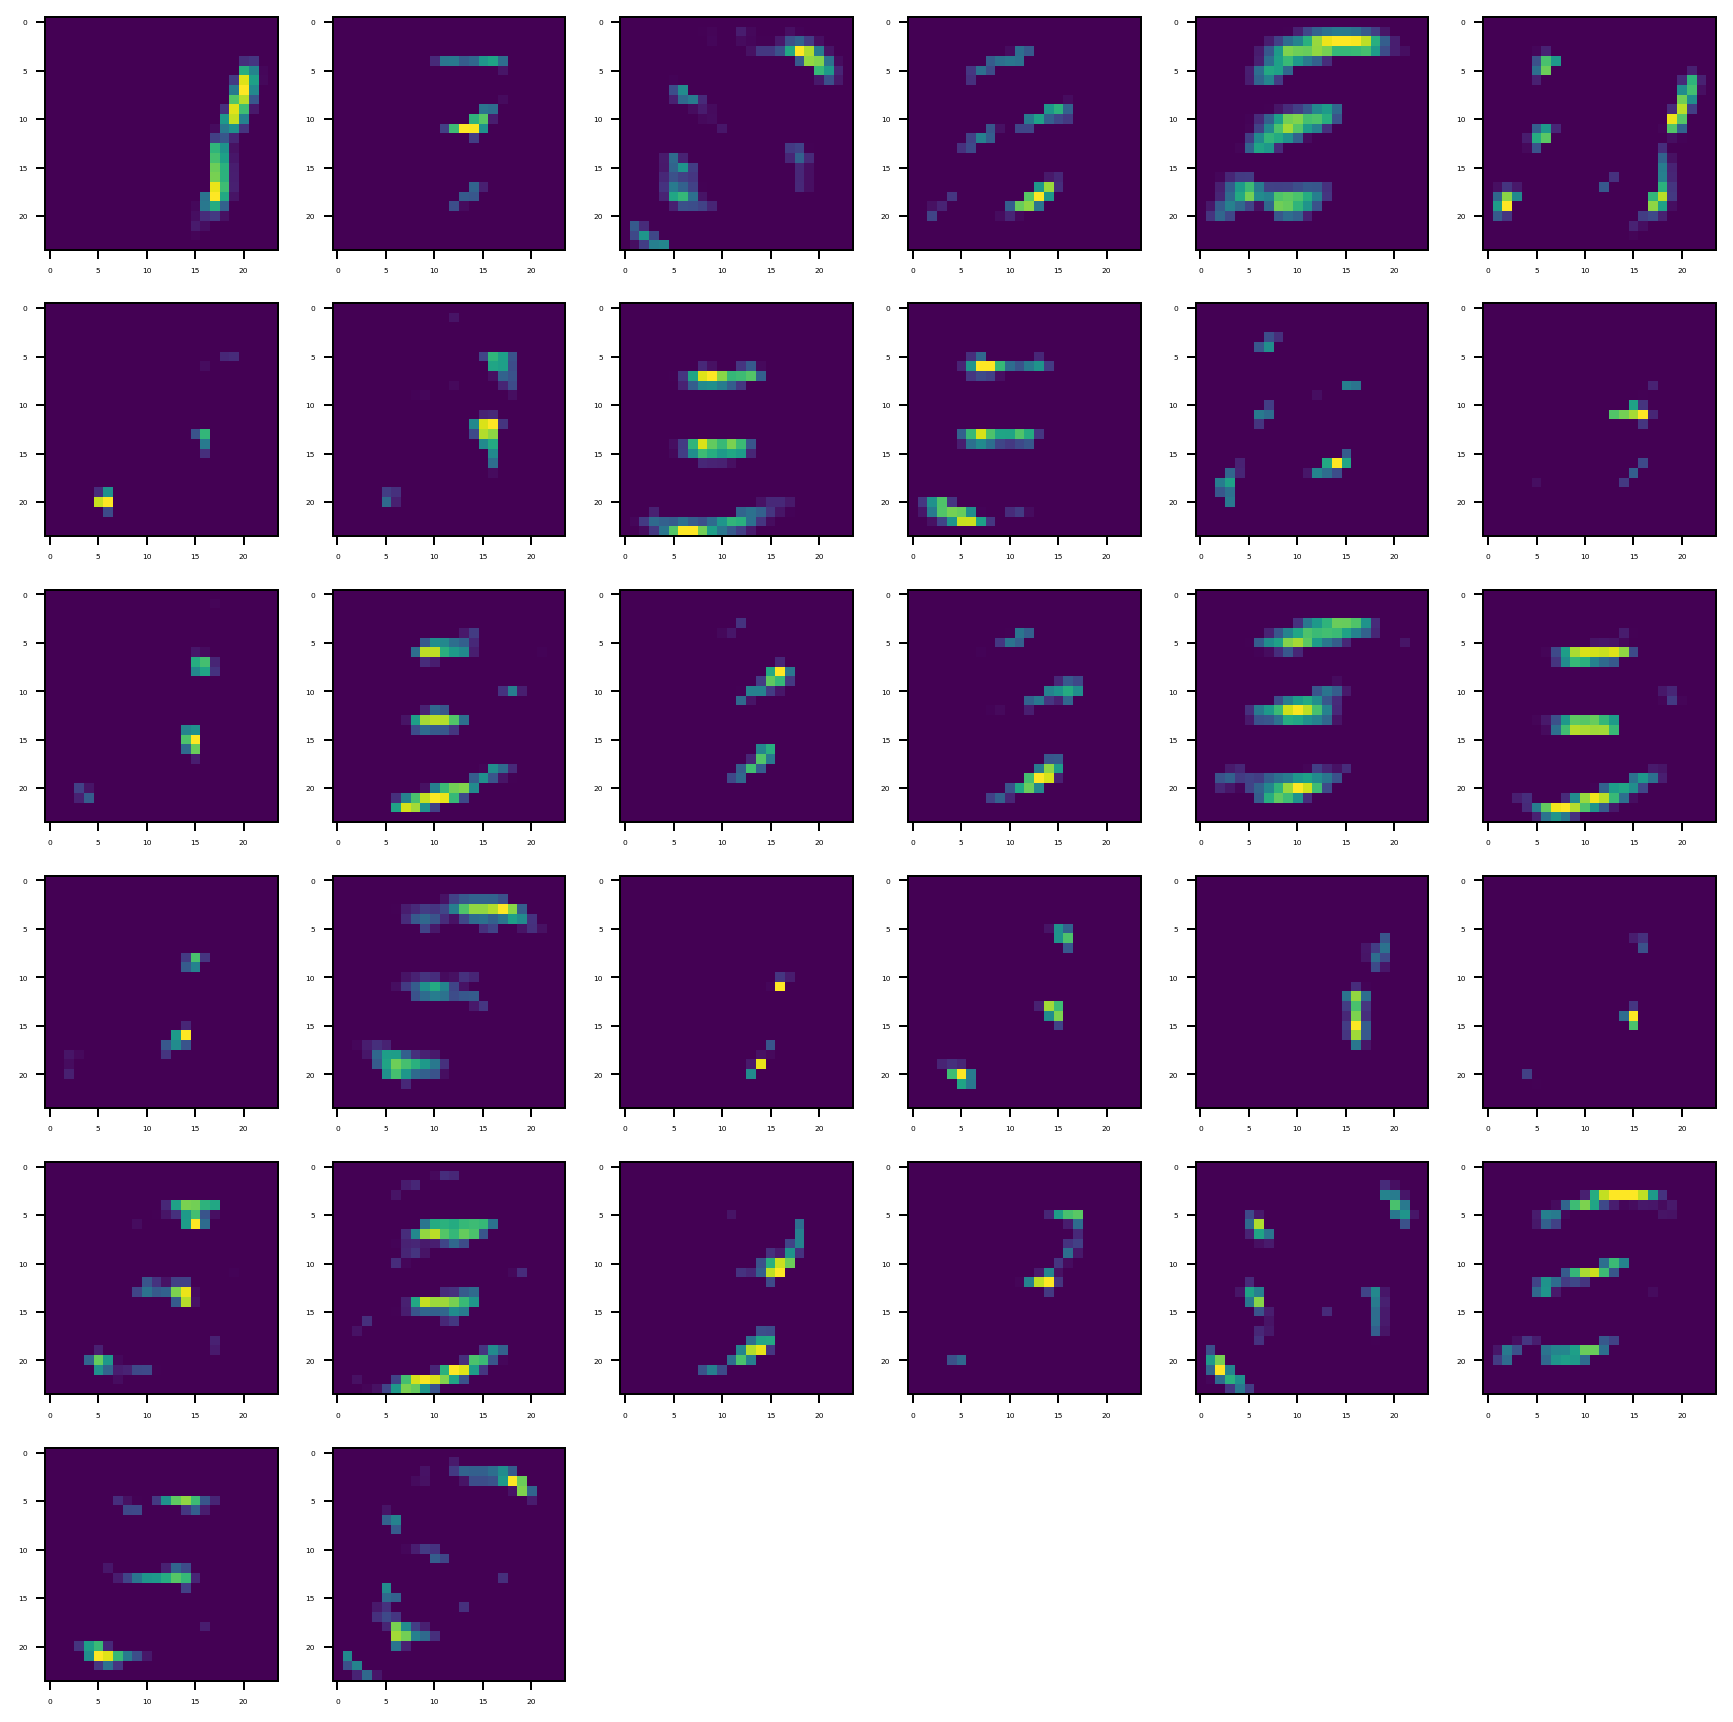

In [41]:
print('Type of layer: ', layer_names[4])
display_activation(activations, 4, 6, (12,12))

Type of layer:  max
Shape of layer:  (1, 12, 12, 32)


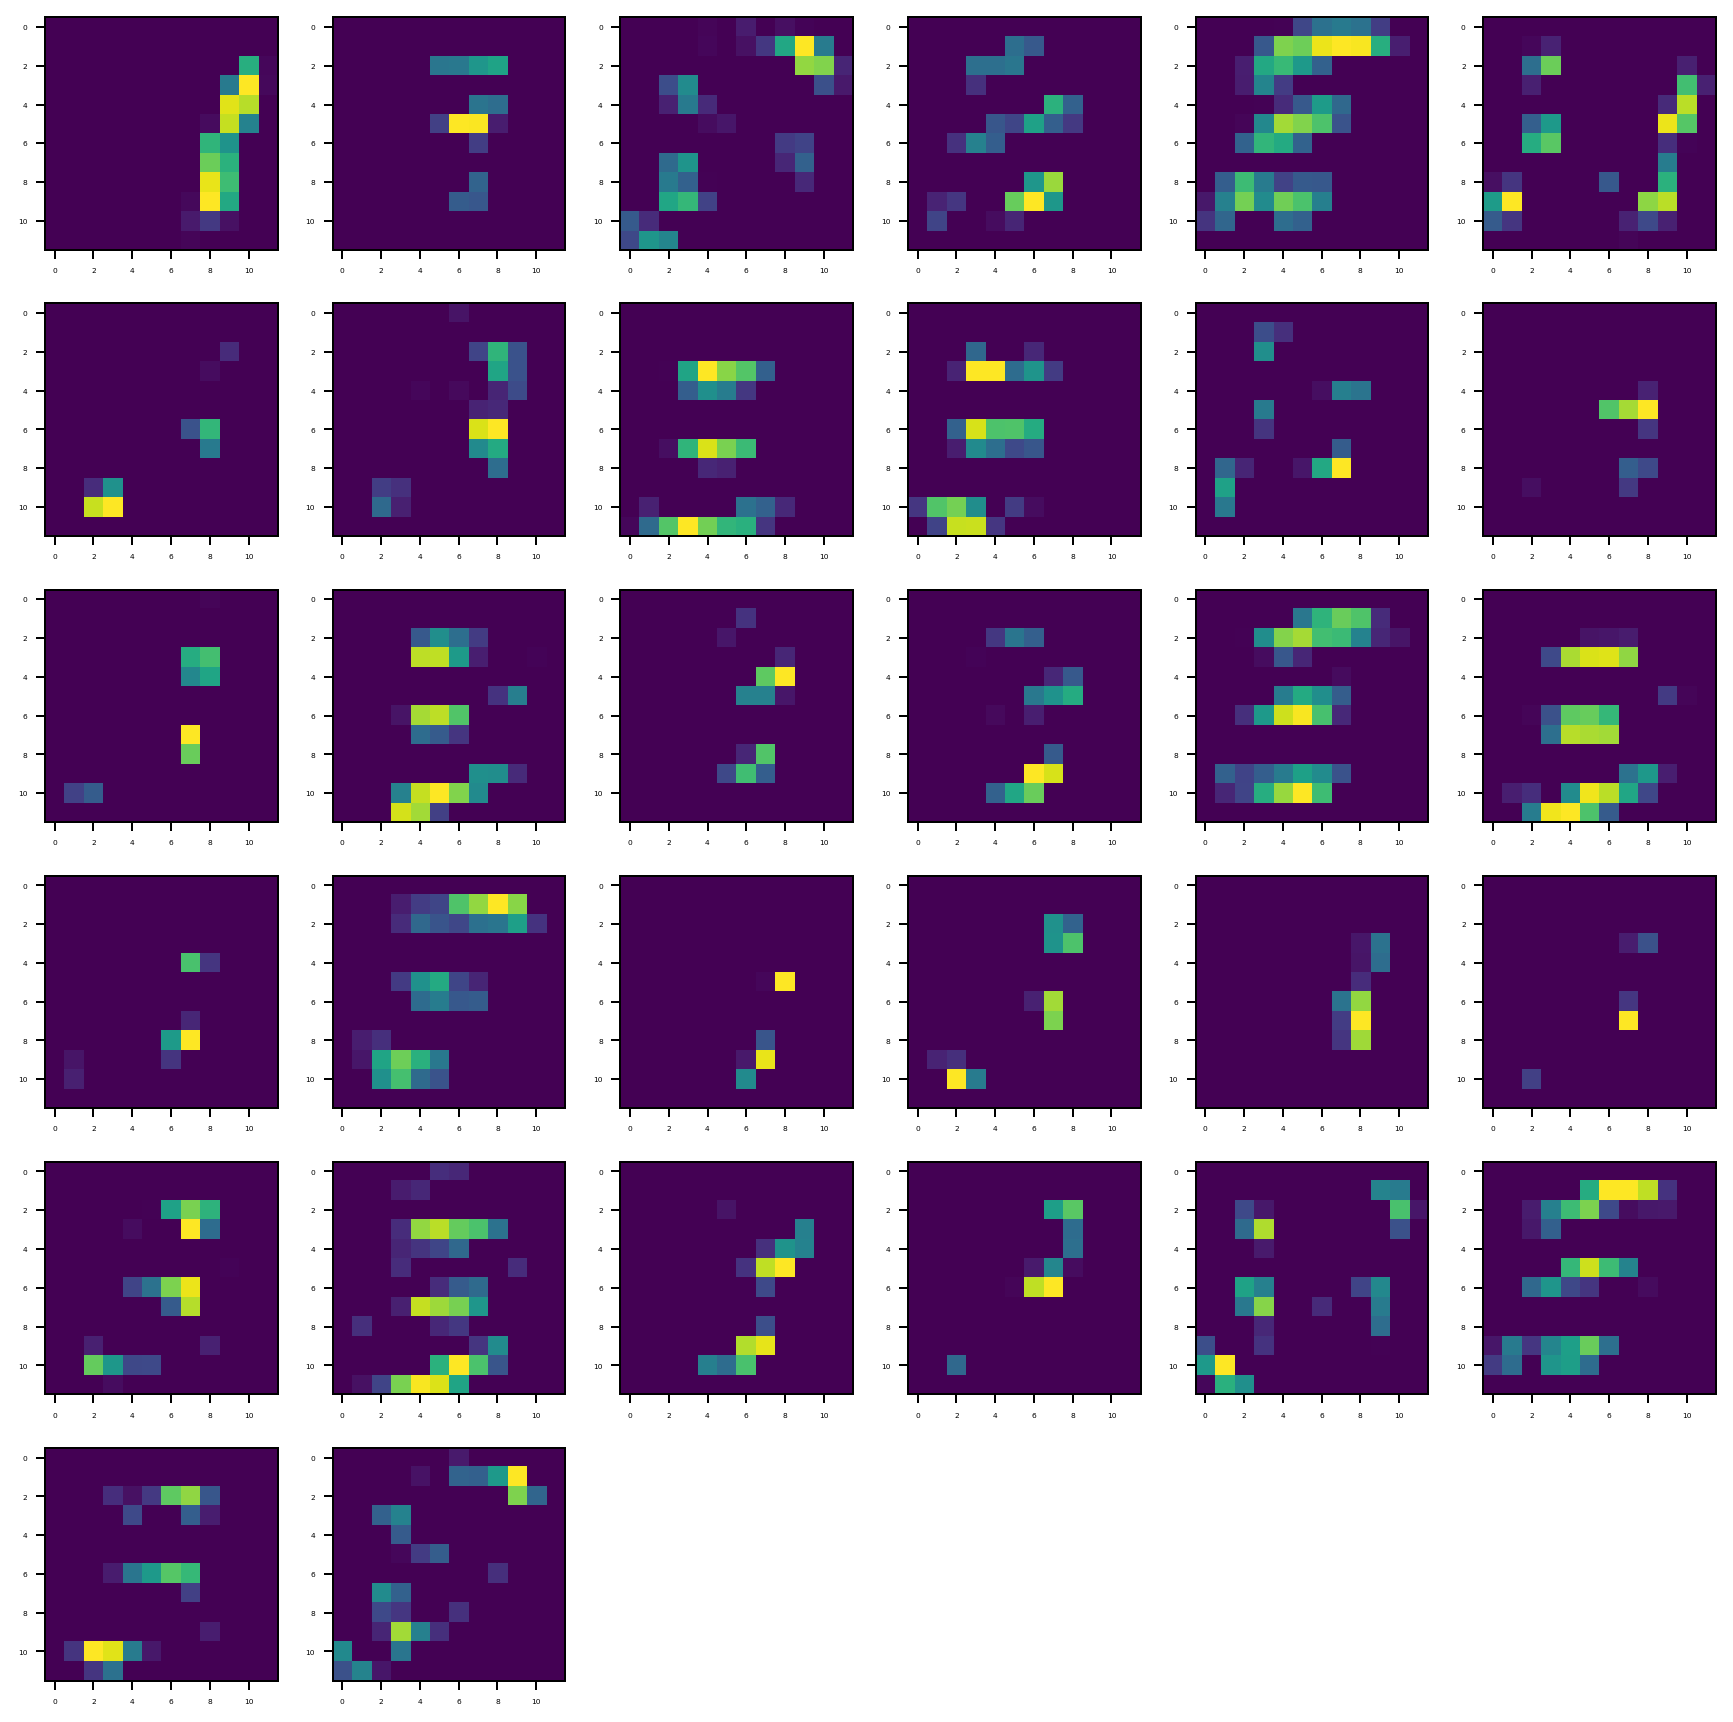

In [42]:
print('Type of layer: ', layer_names[5])
display_activation(activations, 5, 6, (12,12))

Type of layer:  dropout
Shape of layer:  (1, 12, 12, 32)


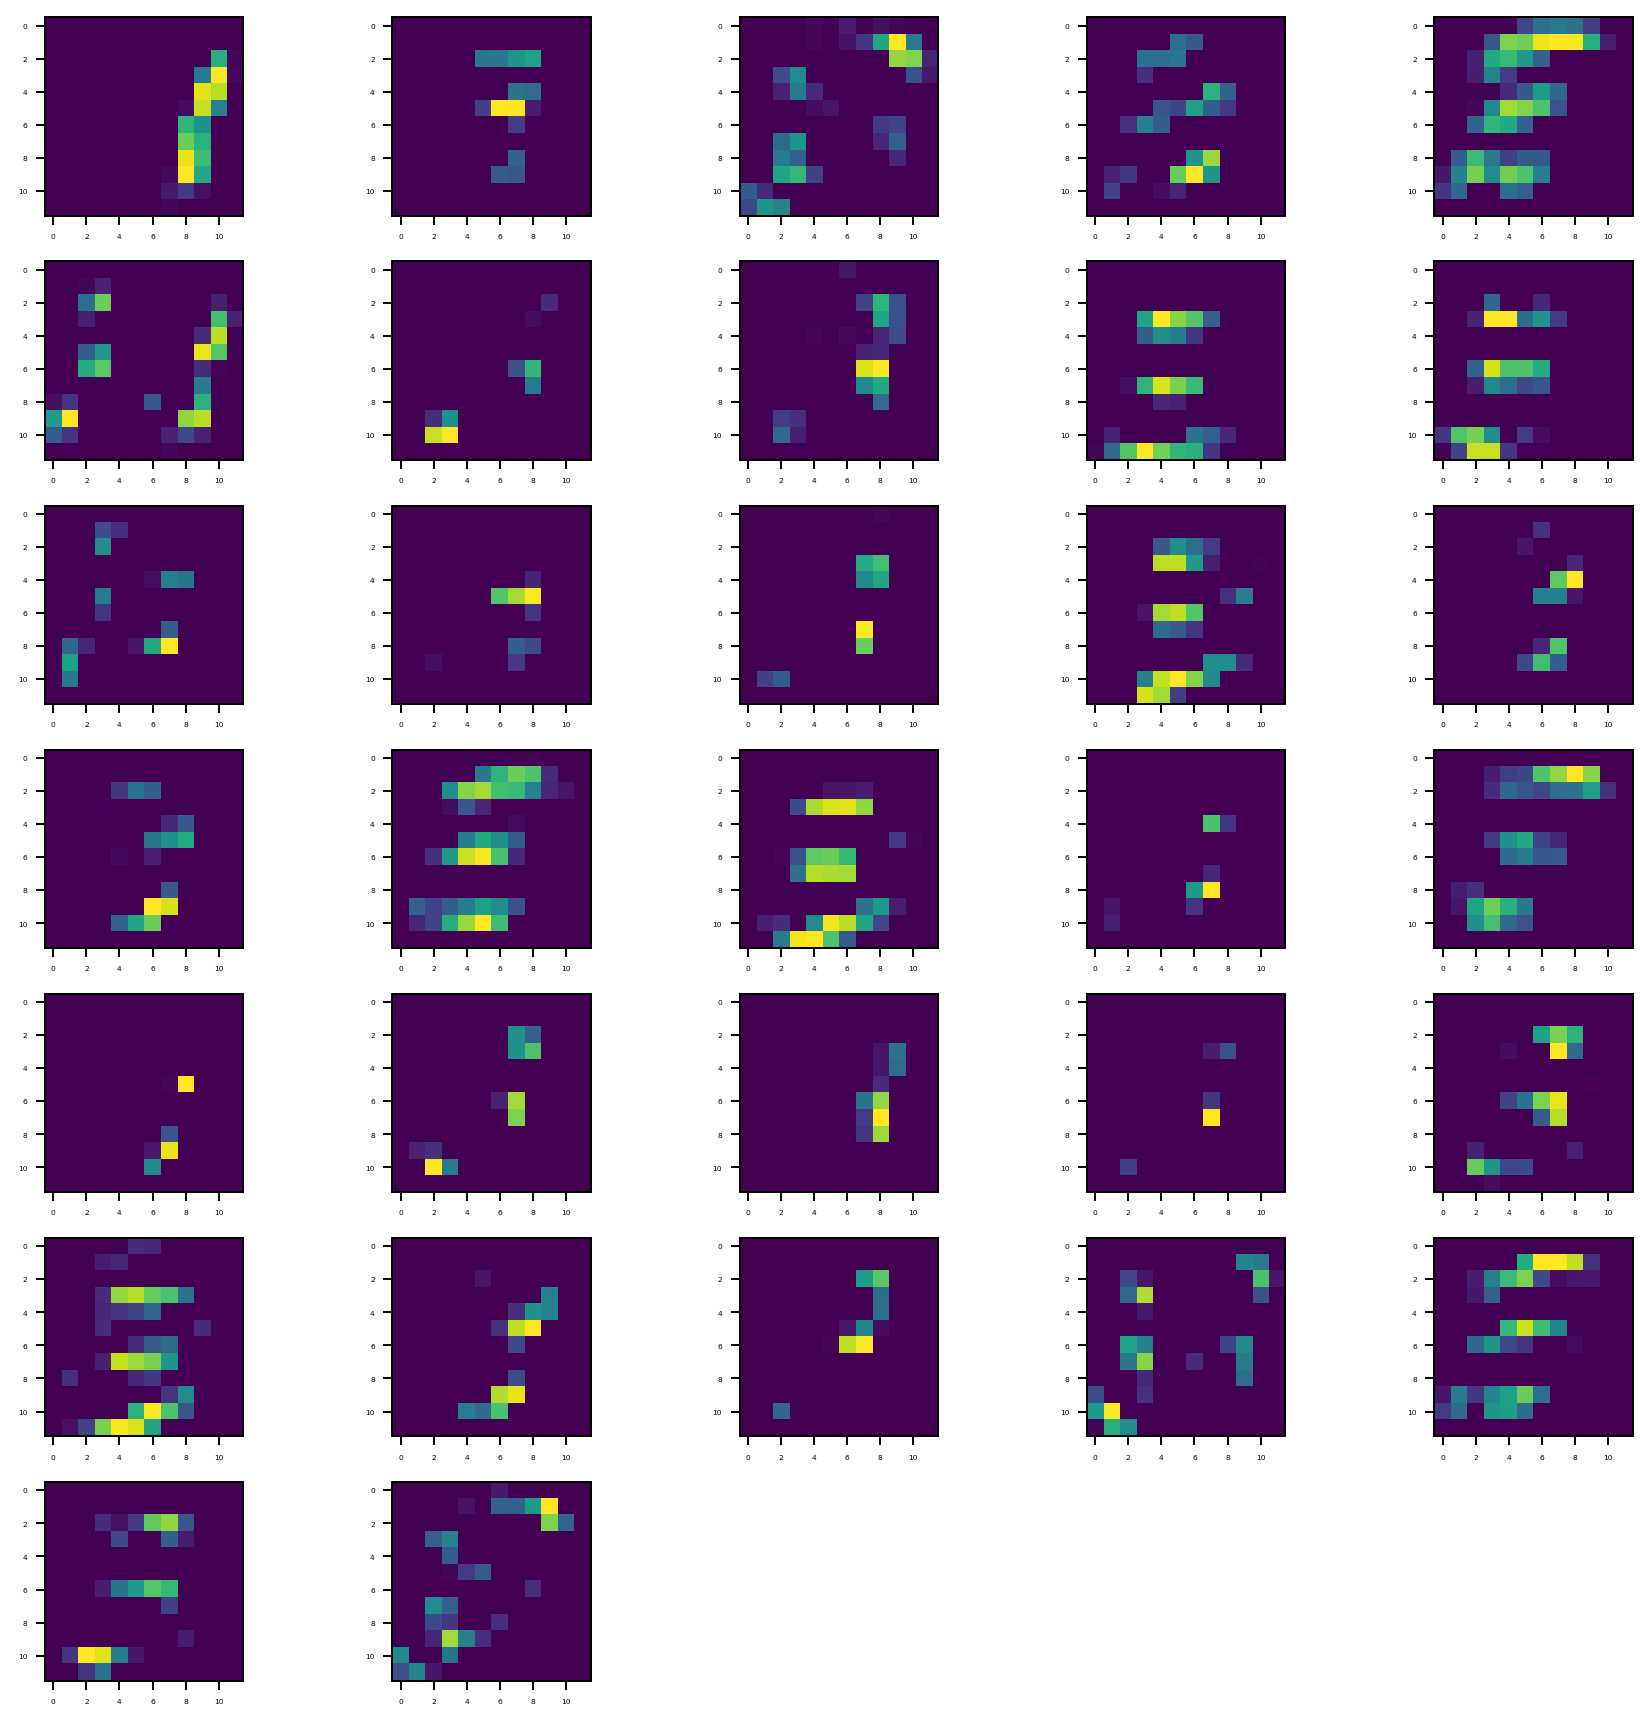

In [43]:
print('Type of layer: ', layer_names[6])
display_activation(activations, 6)

Type of layer:  flatten
Shape of layer:  (1, 4608)


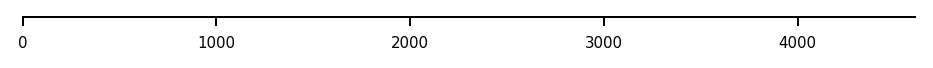

In [44]:
print('Type of layer: ', layer_names[7])
display_activation(activations, 7, 1)

Type of layer:  dense
Shape of layer:  (1, 128)


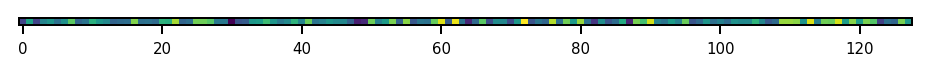

In [45]:
print('Type of layer: ', layer_names[8])
display_activation(activations, 8, 1)

Type of layer:  activation
Shape of layer:  (1, 128)


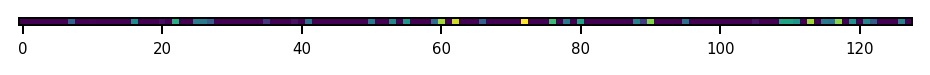

In [46]:
print('Type of layer: ', layer_names[9])
display_activation(activations, 9, 1)

Type of layer:  dropout
Shape of layer:  (1, 128)


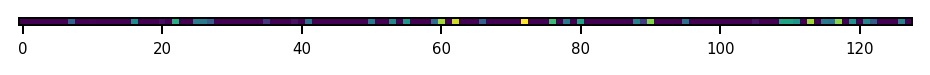

In [47]:
print('Type of layer: ', layer_names[10])
display_activation(activations, 10, 1)

Type of layer:  dense
Shape of layer:  (1, 10)


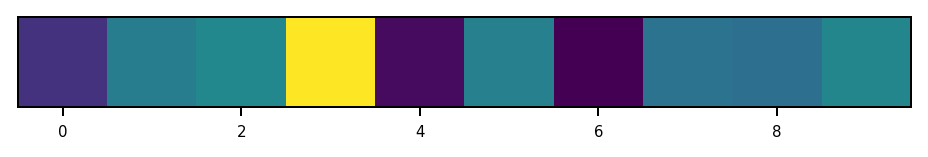

In [48]:
print('Type of layer: ', layer_names[11])
display_activation(activations, 11, 1)

***
# <font color='red'>Confusion matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 


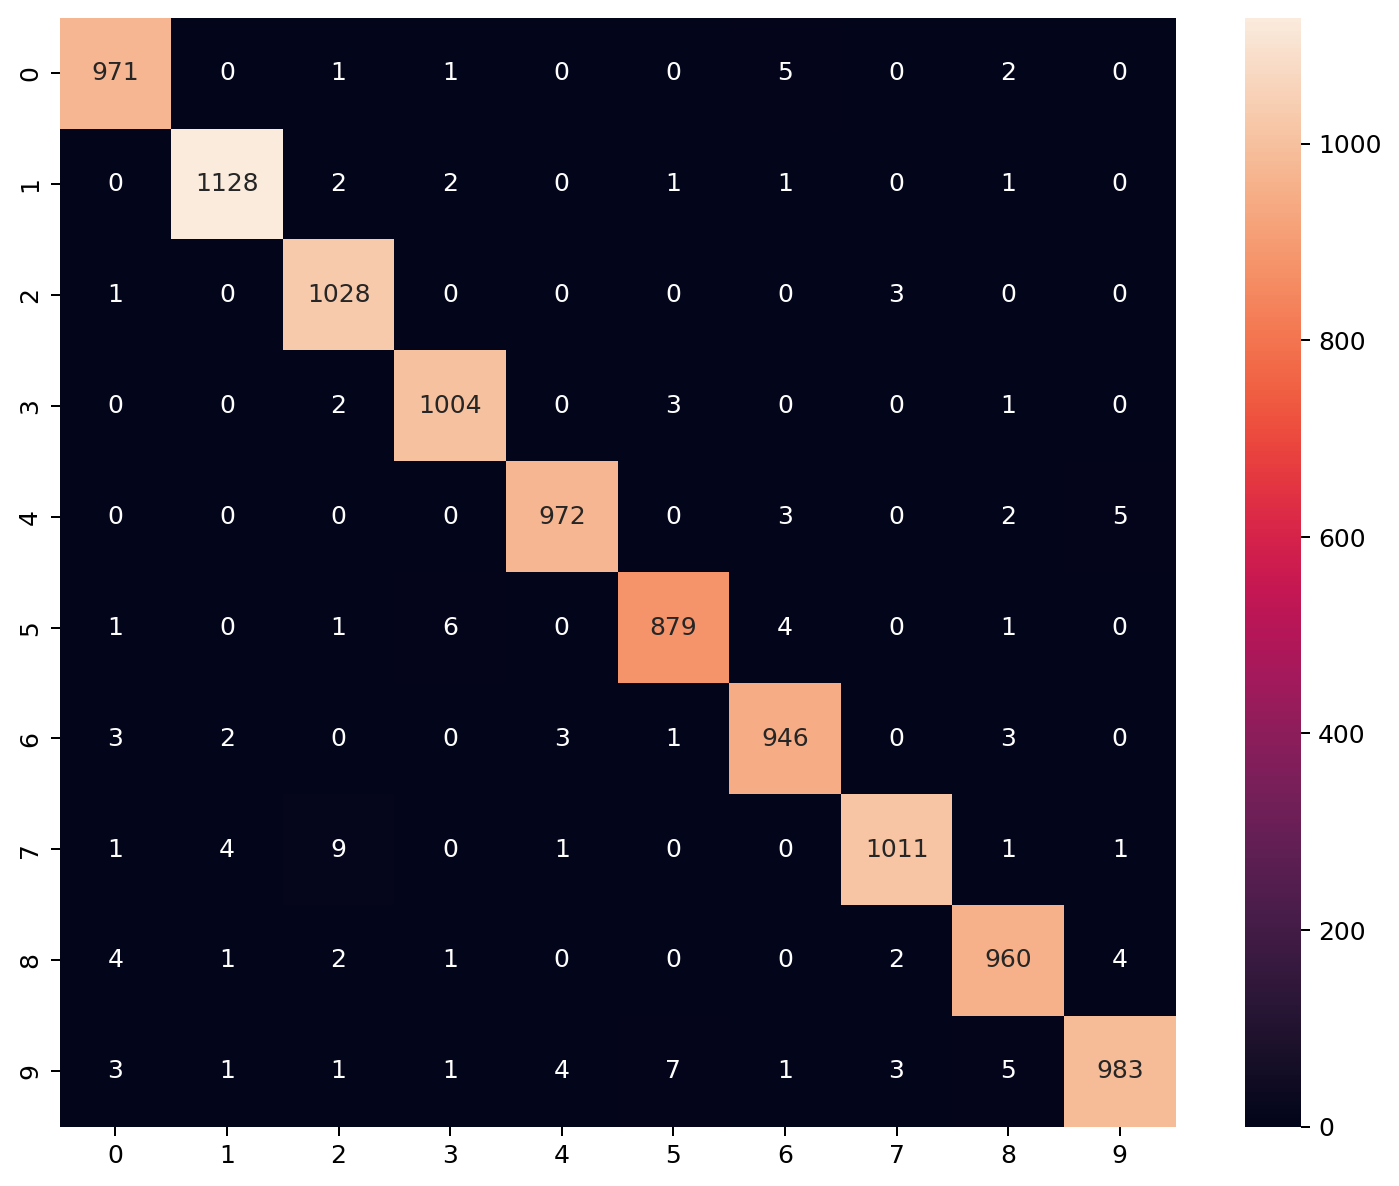

In [49]:
from sklearn.metrics import confusion_matrix

import seaborn as sns

Y_prediction = CNN_model.predict(X_test)

# Convert predictions classes to one hot vectors 
Y_pred_classes = np.argmax(Y_prediction, axis = 1)

# Convert test data to one hot vectors
Y_true = np.argmax(Y_test, axis = 1) 

# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes) 

plt.figure(figsize=(10,8))
sns.heatmap(confusion_mtx, annot=True, fmt="d");

***
# <font color='red'>Build CNN and train/test using PyTorch

In [50]:
X_train.shape, Y_train.shape

((60000, 28, 28, 1), (60000, 10))

In [51]:
Y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# put the tensors in the expected pytorch format
X_trainT = np.transpose(X_train, (0, 3, 1, 2))  # shape: (N, 1, 28, 28)
X_testT = np.transpose(X_test, (0, 3, 1, 2))

# If Y_train is one-hot (e.g., from to_categorical), convert it back:
Y_trainPt = np.argmax(Y_train, axis=1)
Y_testPt = np.argmax(Y_test, axis=1)

# 1. Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_trainT, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_trainPt, dtype=torch.long)
X_test_tensor = torch.tensor(X_testT, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_testPt, dtype=torch.long)

# 2. Build datasets and loaders
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

# 3. Define CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # Output: 32x28x28
        self.pool = nn.MaxPool2d(2, 2)                            # Output: 32x14x14
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # Output: 64x14x14
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # Conv1 + ReLU + Pool
        x = self.pool(F.relu(self.conv2(x)))   # Conv2 + ReLU + Pool
        x = x.view(-1, 64 * 7 * 7)              # Flatten
        x = F.relu(self.fc1(x))                # FC1
        x = self.fc2(x)                        # FC2 → logits
        return x

# 4. Instantiate model, loss, optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Train loop with logging
epochs = 5
for epoch in range(epochs):
    start_time = time.time()

    model.train()
    total_loss = 0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Optional: log every 100 batches
        if (batch_idx + 1) % 20 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} — Batch Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    end_time = time.time()
    epoch_duration = end_time - start_time

    print(f"Epoch {epoch+1}/{epochs} completed — Avg Loss: {avg_loss:.4f} | Time: {epoch_duration:.2f}s\n")

# 6. Evaluate
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

  Batch 20/938 — Batch Loss: 1.6025
  Batch 40/938 — Batch Loss: 0.6454
  Batch 60/938 — Batch Loss: 0.4945
  Batch 80/938 — Batch Loss: 0.3924
  Batch 100/938 — Batch Loss: 0.3050
  Batch 120/938 — Batch Loss: 0.5667
  Batch 140/938 — Batch Loss: 0.2874
  Batch 160/938 — Batch Loss: 0.3186
  Batch 180/938 — Batch Loss: 0.1756
  Batch 200/938 — Batch Loss: 0.1396
  Batch 220/938 — Batch Loss: 0.1976
  Batch 240/938 — Batch Loss: 0.0652
  Batch 260/938 — Batch Loss: 0.1831
  Batch 280/938 — Batch Loss: 0.0471
  Batch 300/938 — Batch Loss: 0.2054
  Batch 320/938 — Batch Loss: 0.0589
  Batch 340/938 — Batch Loss: 0.0391
  Batch 360/938 — Batch Loss: 0.1857
  Batch 380/938 — Batch Loss: 0.1367
  Batch 400/938 — Batch Loss: 0.0672
  Batch 420/938 — Batch Loss: 0.0754
  Batch 440/938 — Batch Loss: 0.0551
  Batch 460/938 — Batch Loss: 0.1710
  Batch 480/938 — Batch Loss: 0.1547
  Batch 500/938 — Batch Loss: 0.0536
  Batch 520/938 — Batch Loss: 0.0990
  Batch 540/938 — Batch Loss: 0.0380
  Bat

***
With a more verbose reporting, by Epoch, similar to Keras

In [53]:
import time

def evaluate(model, loader, criterion):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return accuracy, avg_loss



In [54]:
# Training loop
epochs = 5
for epoch in range(epochs):
    start_time = time.time()
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

    # Evaluation on validation set
    val_acc, val_loss = evaluate(model, test_loader, criterion)

    end_time = time.time()
    duration = end_time - start_time
    step_time_ms = (duration / len(train_loader)) * 1000

    train_acc = correct / total
    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"{len(train_loader)}/{len(train_loader)} — {int(duration)}s — {int(step_time_ms)}ms/step — "
          f"accuracy: {train_acc:.4f} — loss: {avg_loss:.4f} — val_accuracy: {val_acc:.4f} — val_loss: {val_loss:.4f}\n")

Epoch 1/5
938/938 — 104s — 111ms/step — accuracy: 0.9950 — loss: 0.0154 — val_accuracy: 0.9902 — val_loss: 0.0300

Epoch 2/5
938/938 — 105s — 112ms/step — accuracy: 0.9955 — loss: 0.0135 — val_accuracy: 0.9925 — val_loss: 0.0235

Epoch 3/5
938/938 — 103s — 110ms/step — accuracy: 0.9970 — loss: 0.0092 — val_accuracy: 0.9912 — val_loss: 0.0294

Epoch 4/5
938/938 — 103s — 110ms/step — accuracy: 0.9973 — loss: 0.0081 — val_accuracy: 0.9916 — val_loss: 0.0296

Epoch 5/5
938/938 — 108s — 115ms/step — accuracy: 0.9979 — loss: 0.0072 — val_accuracy: 0.9883 — val_loss: 0.0424

